# algo grover phases arbitraires

On compare deux approches :

1. **Grover standard**, utilisé seulement comme référence numérique.
2. **Algorithme généralisé de l'article**, avec phases arbitraires \(\theta,\phi\), état initial quasi-arbitraire et condition de phase matching.

Objectifs :

- calculer la probabilité de succès de ton algorithme ;
- comparer avec Grover standard ;
- afficher l'itération optimale ;
- étudier l'effet d'un mauvais choix de phase ;
- comparer les performances pour plusieurs valeurs de \(N\).

Dépendances :

```python
numpy
matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

## 1. Paramètres globaux

Pour une seule cible parmi \(N\) états, on prend :

\[
\sin\beta=\frac{1}{\sqrt N}.
\]

Dans l'article, l'état initial de l'algorithme généralisé est :

\[
|\psi_0\rangle=
\sin\theta_0 |1\rangle+
\cos\theta_0 e^{i\delta}|2\rangle .
\]

La probabilité initiale de succès de l'algorithme généralisé est donc :

\[
P_0=\sin^2\theta_0.
\]

In [2]:
# Taille de la base
N = 64

# Paramètre beta : une cible parmi N
beta = np.arcsin(1 / np.sqrt(N))

# Paramètres de ton algorithme généralisé
theta0 = 0.28
delta = 0.65
theta = 0.82 * np.pi

print("N =", N)
print("beta =", beta)
print("sin(beta)^2 =", np.sin(beta)**2)
print("theta0 =", theta0)
print("delta =", delta)
print("theta =", theta)
print("Probabilité initiale de ton algo =", np.sin(theta0)**2)
print("Probabilité initiale Grover standard =", 1/N)

N = 64
beta = 0.1253278311680654
sin(beta)^2 = 0.015625
theta0 = 0.28
delta = 0.65
theta = 2.57610597594363
Probabilité initiale de ton algo = 0.07637244449329196
Probabilité initiale Grover standard = 0.015625


## 2. Condition générale de phase matching

La condition centrale de l'article est :

\[
\tan\frac{\theta}{2}
\left[
\cos 2\beta+\tan\theta_0\cos\delta\sin 2\beta
\right]
=
\tan\frac{\phi}{2}
\left[
1-\tan\theta_0\sin\delta\sin 2\beta\tan\frac{\theta}{2}
\right].
\]

On l'utilise pour calculer la phase \(\phi\) adaptée à l'algorithme.

In [3]:
def phase_error(theta, phi, beta, theta0, delta):
    lhs = np.tan(theta / 2) * (
        np.cos(2 * beta) + np.tan(theta0) * np.cos(delta) * np.sin(2 * beta)
    )
    rhs = np.tan(phi / 2) * (
        1 - np.tan(theta0) * np.sin(delta) * np.sin(2 * beta) * np.tan(theta / 2)
    )
    return np.abs(lhs - rhs)

def phi_matched(theta, beta, theta0, delta):
    numerator = np.tan(theta / 2) * (
        np.cos(2 * beta) + np.tan(theta0) * np.cos(delta) * np.sin(2 * beta)
    )
    denominator = (
        1 - np.tan(theta0) * np.sin(delta) * np.sin(2 * beta) * np.tan(theta / 2)
    )
    return 2 * np.arctan(numerator / denominator)

phi = phi_matched(theta, beta, theta0, delta)

print("phi calculé par phase matching =", phi)
print("erreur de matching =", phase_error(theta, phi, beta, theta0, delta))

phi calculé par phase matching = 2.6682263850454255
erreur de matching = 8.881784197001252e-16


## 3. Matrice de ton algorithme généralisé

L'évolution est simulée dans le sous-espace \(\{|1\rangle,|2\rangle\}\).

La probabilité de succès après \(j\) itérations est :

\[
P_j = |\langle 1|\psi_j\rangle|^2.
\]

In [4]:
def Q_general(theta, phi, beta):
    s = np.sin(beta)
    c = np.cos(beta)
    eitheta = np.exp(1j * theta)
    eiphi = np.exp(1j * phi)

    return np.array([
        [
            -eiphi * (1 + (eitheta - 1) * s**2),
            -(eitheta - 1) * s * c
        ],
        [
            -eiphi * (eitheta - 1) * s * c,
            -eitheta + (eitheta - 1) * s**2
        ]
    ], dtype=complex)

def initial_state_general(theta0, delta):
    return np.array([
        np.sin(theta0),
        np.cos(theta0) * np.exp(1j * delta)
    ], dtype=complex)

def success_prob_general(theta, phi, beta, theta0, delta, n_steps=100):
    Q = Q_general(theta, phi, beta)
    psi = initial_state_general(theta0, delta)
    probs = []

    for _ in range(n_steps + 1):
        probs.append(np.abs(psi[0])**2)
        psi = Q @ psi
        psi = psi / np.linalg.norm(psi)

    return np.array(probs)

probs_algo = success_prob_general(theta, phi, beta, theta0, delta, n_steps=100)

print("Probabilité de succès maximale de ton algo =", probs_algo.max())
print("Itération optimale de ton algo =", probs_algo.argmax())

Probabilité de succès maximale de ton algo = 0.9993068289753556
Itération optimale de ton algo = 44


## 4. Référence : Grover standard en deux dimensions

On utilise Grover standard seulement comme référence.

Dans le sous-espace marqué/non marqué :

\[
|\psi_0\rangle =
\sin\beta |1\rangle+\cos\beta |2\rangle.
\]

La probabilité de succès après \(j\) itérations vaut :

\[
P_j^{Grover}=\sin^2((2j+1)\beta).
\]

In [5]:
def success_prob_grover_standard(beta, n_steps=100):
    j = np.arange(n_steps + 1)
    return np.sin((2*j + 1) * beta)**2

probs_grover = success_prob_grover_standard(beta, n_steps=100)

print("Probabilité de succès maximale Grover standard =", probs_grover.max())
print("Itération optimale Grover standard =", probs_grover.argmax())

Probabilité de succès maximale Grover standard = 0.9999346466157216
Itération optimale Grover standard = 81


## 5. Comparaison directe des probabilités de succès

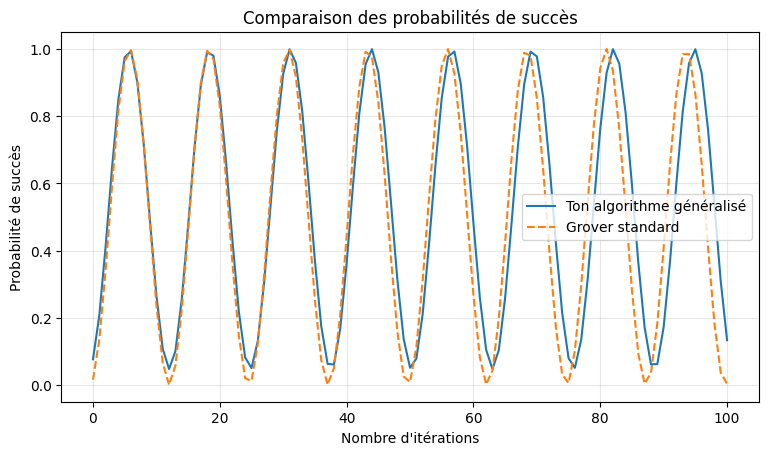

Résumé
-----------------------------------------------------------------
Ton algo      : Pmax = 0.999307, j_opt = 44
Grover std    : Pmax = 0.999935, j_opt = 81
P0 ton algo   : 0.076372
P0 Grover std : 0.015625


In [6]:
n_steps = 100

probs_algo = success_prob_general(theta, phi, beta, theta0, delta, n_steps=n_steps)
probs_grover = success_prob_grover_standard(beta, n_steps=n_steps)

plt.figure(figsize=(9, 4.8))
plt.plot(probs_algo, label="Ton algorithme généralisé")
plt.plot(probs_grover, "--", label="Grover standard")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Probabilité de succès")
plt.title("Comparaison des probabilités de succès")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Résumé")
print("-" * 65)
print(f"Ton algo      : Pmax = {probs_algo.max():.6f}, j_opt = {probs_algo.argmax()}")
print(f"Grover std    : Pmax = {probs_grover.max():.6f}, j_opt = {probs_grover.argmax()}")
print(f"P0 ton algo   : {probs_algo[0]:.6f}")
print(f"P0 Grover std : {probs_grover[0]:.6f}")

## 6. Tableau comparatif à quelques itérations

In [7]:
selected_iterations = [0, 1, 2, 3, 4, 5, 8, 10, 15, 20, 25, 30, 40, 50]

print("j | P ton algo | P Grover standard | différence")
print("-" * 56)

for j in selected_iterations:
    if j <= n_steps:
        diff = probs_algo[j] - probs_grover[j]
        print(f"{j:2d} | {probs_algo[j]:10.6f} | {probs_grover[j]:17.6f} | {diff: .6f}")

j | P ton algo | P Grover standard | différence
--------------------------------------------------------
 0 |   0.076372 |          0.015625 |  0.060747
 1 |   0.207190 |          0.134827 |  0.072363
 2 |   0.413392 |          0.343895 |  0.069497
 3 |   0.645860 |          0.591380 |  0.054480
 4 |   0.849218 |          0.816377 |  0.032841
 5 |   0.975024 |          0.963515 |  0.011509
 8 |   0.716549 |          0.718042 | -0.001493
10 |   0.266938 |          0.238068 |  0.028870
15 |   0.472692 |          0.458221 |  0.014472
20 |   0.859862 |          0.829200 |  0.030662
25 |   0.050237 |          0.011733 |  0.038503
30 |   0.925844 |          0.956958 | -0.031114
40 |   0.361469 |          0.441512 | -0.080044
50 |   0.051292 |          0.008393 |  0.042900


## 7. Comparaison avec phase mismatch

On vérifie si la performance de l'algorithme dépend fortement du bon choix de \(\phi\).

On compare :

\[
\phi,\quad \phi+0.05,\quad \phi+0.10,\quad \phi+0.20.
\]

epsilon | erreur matching | Pmax | j_opt
-------------------------------------------------------
   0.00 |   8.881784e-16 | 0.999307 |    44
   0.05 |   4.320149e-01 | 0.990804 |    80
   0.10 |   9.778031e-01 | 0.961088 |    89
   0.20 |   2.660456e+00 | 0.884444 |    93


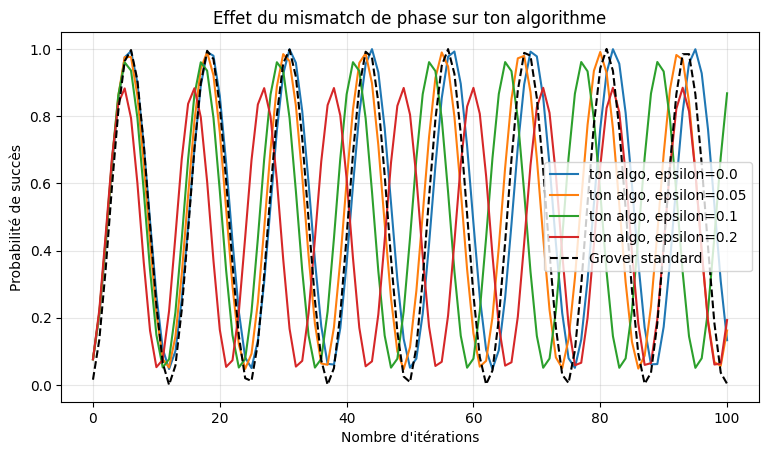

In [8]:
epsilons = [0.0, 0.05, 0.10, 0.20]

plt.figure(figsize=(9, 4.8))

print("epsilon | erreur matching | Pmax | j_opt")
print("-" * 55)

for eps in epsilons:
    p = success_prob_general(theta, phi + eps, beta, theta0, delta, n_steps=n_steps)
    plt.plot(p, label=f"ton algo, epsilon={eps}")
    print(f"{eps:7.2f} | {phase_error(theta, phi + eps, beta, theta0, delta):14.6e} | {p.max():.6f} | {p.argmax():5d}")

plt.plot(probs_grover, "k--", label="Grover standard")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Probabilité de succès")
plt.title("Effet du mismatch de phase sur ton algorithme")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Comparaison en fonction de la taille \(N\)

Pour chaque \(N\), on calcule :

- \(P_{\max}\) ;
- l'itération optimale ;
- la probabilité initiale.

In [9]:
def compare_for_N_values(N_values, theta0, delta, theta):
    rows = []

    for N_val in N_values:
        b = np.arcsin(1 / np.sqrt(N_val))
        ph = phi_matched(theta, b, theta0, delta)
        steps = int(max(30, 3*np.sqrt(N_val)))

        p_algo = success_prob_general(theta, ph, b, theta0, delta, n_steps=steps)
        p_grov = success_prob_grover_standard(b, n_steps=steps)

        rows.append([
            N_val,
            ph,
            p_algo[0],
            p_algo.max(),
            int(p_algo.argmax()),
            p_grov[0],
            p_grov.max(),
            int(p_grov.argmax())
        ])

    return rows

N_values = [16, 32, 64, 128, 256, 512, 1024]
rows = compare_for_N_values(N_values, theta0, delta, theta)

print("N | phi_match | P0_algo | Pmax_algo | j_algo | P0_grover | Pmax_grover | j_grover")
print("-" * 96)

for row in rows:
    print(
        f"{row[0]:4d} | {row[1]:9.5f} | {row[2]:8.5f} | {row[3]:9.6f} |"
        f" {row[4]:6d} | {row[5]:9.6f} | {row[6]:11.6f} | {row[7]:8d}"
    )

N | phi_match | P0_algo | Pmax_algo | j_algo | P0_grover | Pmax_grover | j_grover
------------------------------------------------------------------------------------------------
  16 |   2.72906 |  0.07637 |  0.995587 |      9 |  0.062500 |    0.999564 |       15
  32 |   2.69689 |  0.07637 |  0.999978 |      4 |  0.031250 |    0.999182 |        4
  64 |   2.66823 |  0.07637 |  0.993311 |      6 |  0.015625 |    0.996586 |        6
 128 |   2.64482 |  0.07637 |  0.999983 |      8 |  0.007812 |    0.999530 |       26
 256 |   2.62658 |  0.07637 |  0.999782 |     37 |  0.003906 |    0.999947 |       12
 512 |   2.61278 |  0.07637 |  0.999938 |     16 |  0.001953 |    0.999679 |       53
1024 |   2.60255 |  0.07637 |  0.999849 |     74 |  0.000977 |    0.999949 |       75


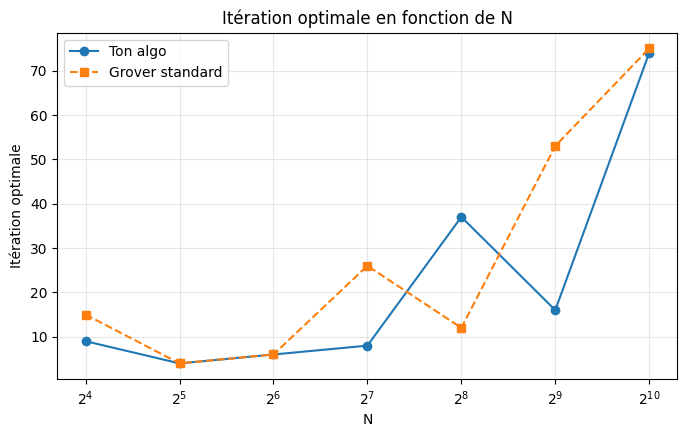

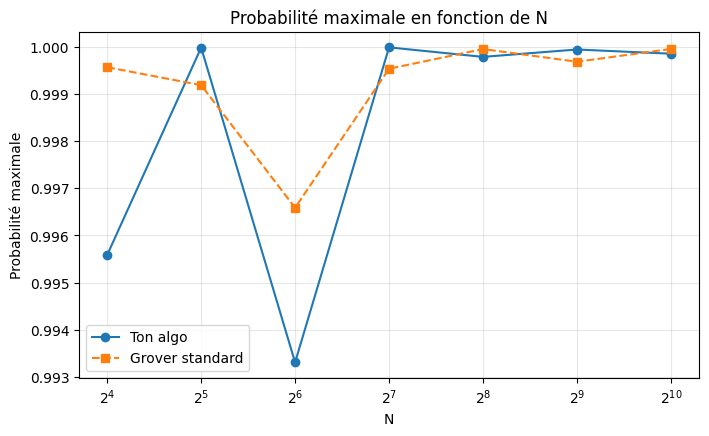

In [10]:
N_array = np.array([row[0] for row in rows])
j_algo_array = np.array([row[4] for row in rows])
j_grover_array = np.array([row[7] for row in rows])
pmax_algo_array = np.array([row[3] for row in rows])
pmax_grover_array = np.array([row[6] for row in rows])

plt.figure(figsize=(8, 4.5))
plt.plot(N_array, j_algo_array, "o-", label="Ton algo")
plt.plot(N_array, j_grover_array, "s--", label="Grover standard")
plt.xlabel("N")
plt.ylabel("Itération optimale")
plt.title("Itération optimale en fonction de N")
plt.xscale("log", base=2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(N_array, pmax_algo_array, "o-", label="Ton algo")
plt.plot(N_array, pmax_grover_array, "s--", label="Grover standard")
plt.xlabel("N")
plt.ylabel("Probabilité maximale")
plt.title("Probabilité maximale en fonction de N")
plt.xscale("log", base=2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. Interprétation

Ici :

- la probabilité de succès de l'algorithme est calculée directement par :
  \[
  P_j = |\langle 1|\psi_j\rangle|^2 ;
  \]
- Grover standard sert de référence avec :
  \[
  P_j^{Grover}=\sin^2((2j+1)\beta) ;
  \]
- la phase \(\phi\) de ton algorithme est calculée par la condition de matching de l'article ;
- on observe que le résultat dépend fortement de l'état initial \((\theta_0,\delta)\) et du bon appariement des phases.

Remarque importante : si l'état initial a déjà une probabilité marquée plus grande que \(1/N\), l'algorithme peut démarrer avec un avantage initial par rapport à Grover standard. La comparaison doit donc être interprétée en tenant compte de \(P_0\).